# Classwork : pandas

-  introductory guide to using the Pandas library in Python for data manipulation and analysis.
-  foundational concepts such as Series (1D data) and DataFrame (2D labeled data), and how to create them using pd.Series() and pd.DataFrame().
-   examples for slicing, viewing rows (head, tail), filtering with conditions, and sorting with sort_index().
- key operations like dropping rows or columns, removing duplicates, grouping and aggregating data, and basic plotting.

In [2]:
import pandas as pd

In [19]:
from google.colab import drive
drive.mount('/content/drive/')

import os

os.chdir('/content/drive/My Drive/GU/hw1/')

Mounted at /content/drive/


In [20]:
csv_file = 'panchyat_episode.csv'


# Series and Datafame

In [63]:
# Creating a Pandas Series
series_num = pd.Series([1, 3, 5, None, 6, 8])
series_num

,0
0,1.0
1,3.0
2,5.0
3,NaN
4,6.0
5,8.0


In [64]:
# next example series with text data

series_animal = pd.Series(['lion','tiger','ant','cow', 'dog', 'cat'])
series_animal

,0
0,lion
1,tiger
2,ant
3,cow
4,dog
5,cat


In [65]:
# next example series with text data

series_fruit = pd.Series(['mango','pappaya','grapes','apple', 'banana', 'cherry'])
series_fruit

,0
0,mango
1,pappaya
2,grapes
3,apple
4,banana
5,cherry


In [66]:
print(type(series_fruit))

<class 'pandas.core.series.Series'>


In [88]:

series_food = pd.Series(['momo', 'rice', 'dal', 'bhat', 'tarkari', 'aachar'])

# Create DataFrame with all series as columns
df_new = pd.DataFrame({
    'food': series_food,
    'cost': series_num,
    'animal': series_animal,
    'fruit': series_fruit
})

#  set 'food' as index
df_new.set_index('food', inplace=True)


display(df_new)


,cost,animal,fruit
food,,,
momo,1.0,lion,mango
rice,3.0,tiger,pappaya
dal,5.0,ant,grapes
bhat,NaN,cow,apple
tarkari,6.0,dog,banana
aachar,8.0,cat,cherry


In [89]:
df2 = df_new.iloc[2:5, 1:3]
df2

,animal,fruit
food,,
dal,ant,grapes
bhat,cow,apple
tarkari,dog,banana


In [92]:
display(df2)
df2.sort_index()

,animal,fruit
food,,
dal,ant,grapes
bhat,cow,apple
tarkari,dog,banana


,animal,fruit
food,,
bhat,cow,apple
dal,ant,grapes
tarkari,dog,banana


In [91]:
# Creating a DataFrame from a dictionary
data = {'col1': [1, 2, 3], 'col2': ['A', 'B', 'C']}
df = pd.DataFrame(data)
df

,col1,col2
0,1,A
1,2,B
2,3,C


In [76]:
df.describe()

,col1
count,3.0
mean,2.0
std,1.0
min,1.0
25%,1.5
50%,2.0
75%,2.5
max,3.0


In [73]:
print(type(data))
print(type(df))

<class 'dict'>
<class 'pandas.core.frame.DataFrame'>


In [74]:
df.loc[0] # label-based (uses row/column names)

,0
col1,1
col2,A


In [11]:
df.loc[0,'col1']

np.int64(1)

In [12]:
df.iloc[0] #position-based (uses row/column index)

,0
col1,1
col2,A


In [14]:
df.iloc[0,'col1'] # notethe error

ValueError: Location based indexing can only have [integer, integer slice (START point is INCLUDED, END point is EXCLUDED), listlike of integers, boolean array] types

In [15]:
df.iloc[0,0]


np.int64(1)

In [16]:
df.head()

,col1,col2
0,1,A
1,2,B
2,3,C


In [17]:
df.head(2)

,col1,col2
0,1,A
1,2,B


## lets play with our existing dataframe


In [28]:
df.head(2)

,No.,Title,Directed by,Written by,Original release date,Description
0,1,"""Gram Panchayat Phulera""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Abhishek Tripathi is a fresh engineering gradu...
1,2,"""Bhootha Ped""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),"Abhishek, working as panchayat secretary, is a..."


In [29]:
df.tail(3)

,No.,Title,Directed by,Written by,Original release date,Description
21,6,"""Chingaari""",Deepak Kumar Mishra,Chandan Kumar,28 May 2024 (2024-05-28),"To fix their dented image, the Pradhan gang se..."
22,7,"""Shola""",Deepak Kumar Mishra,Chandan Kumar,28 May 2024 (2024-05-28),The MLA puts out a hit on one of the village r...
23,8,"""Hamla""",Deepak Kumar Mishra,Chandan Kumar,28 May 2024 (2024-05-28),"Finally, Pradhan rallies the whole Phulera beh..."


In [82]:
# lets remove a column
df.drop('No.', axis=1, inplace=True)


In [83]:
# SLICING
df.loc[0:2,'Title']

,Title
0,"""Gram Panchayat Phulera"""
1,"""Bhootha Ped"""
2,"""Chakke Wali Kursi"""


In [84]:
# SLICING
df.loc[2:5,'Description']

,Description
2,Abhishek buys a comfy revolving chair since wo...
3,Abhishek is instructed by the BDO to put up fa...
4,Frustrated by the lack of nightlife in the vil...
5,Abhishek is having his photograph taken for th...


In [86]:
# SLICING
df.iloc[0:2,1]

,Directed by
0,Deepak Kumar Mishra
1,Deepak Kumar Mishra


In [87]:
# SLICING
df.iloc[0:2,:]

,Title,Directed by,Written by,Original release date,Description
0,"""Gram Panchayat Phulera""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Abhishek Tripathi is a fresh engineering gradu...
1,"""Bhootha Ped""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),"Abhishek, working as panchayat secretary, is a..."


In [35]:
# SLICING
df.iloc[:,0:2]

,Title,Directed by
0,"""Gram Panchayat Phulera""",Deepak Kumar Mishra
1,"""Bhootha Ped""",Deepak Kumar Mishra
2,"""Chakke Wali Kursi""",Deepak Kumar Mishra
3,"""Hamara Neta Kaisa Ho?""",Deepak Kumar Mishra
4,"""Computer Nahi Monitor""",Deepak Kumar Mishra
5,"""Bahot Hua Samman""",Deepak Kumar Mishra
6,"""Ladka Tez Hai Lekin..""",Deepak Kumar Mishra
7,"""Jab Jaago Tabhi Savera""",Deepak Kumar Mishra
8,"""Naach""",Deepak Kumar Mishra
9,"""Bol Chaal Band""",Deepak Kumar Mishra


# More functions

In [36]:
# sample fruit sales  data
data_fruit = {
    'date': pd.date_range(start='2025-01-01', periods=11),
    'fruit': ['apple', 'banana', 'orange', 'apple', 'banana', 'orange', 'apple', 'banana', 'orange', 'apple','apple'],
    'sales_kg': [23, 45, 12, 34, 45, 25, 23, 45, 12, 34, 34],
    'price_per_kg': [2.5, 1.2, 3.0, 2.5, 1.2, 3.0, 2.5, 1.2, 3.0, 2.5, 2.5],
    'shop': ['Bagar', 'Lamachour', 'Batulechour', 'Bagar', 'Lamachour', 'Batulechour', 'Bagar', 'Lamachour', 'Batulechour', 'Bagar', 'Bagar']
}

In [37]:
df = pd.DataFrame(data_fruit)
df

,date,fruit,sales_kg,price_per_kg,shop
0,2025-01-01,apple,23,2.5,Bagar
1,2025-01-02,banana,45,1.2,Lamachour
2,2025-01-03,orange,12,3.0,Batulechour
3,2025-01-04,apple,34,2.5,Bagar
4,2025-01-05,banana,45,1.2,Lamachour
5,2025-01-06,orange,25,3.0,Batulechour
6,2025-01-07,apple,23,2.5,Bagar
7,2025-01-08,banana,45,1.2,Lamachour
8,2025-01-09,orange,12,3.0,Batulechour
9,2025-01-10,apple,34,2.5,Bagar


In [38]:
new_row = {
    'date': pd.Timestamp('2025-01-11'),
    'fruit': 'apple',
    'sales_kg': 34,
    'price_per_kg': 2.5,
    'shop': 'Bagar'
}

# Append the new row to the DataFrame
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
df

,date,fruit,sales_kg,price_per_kg,shop
0,2025-01-01,apple,23,2.5,Bagar
1,2025-01-02,banana,45,1.2,Lamachour
2,2025-01-03,orange,12,3.0,Batulechour
3,2025-01-04,apple,34,2.5,Bagar
4,2025-01-05,banana,45,1.2,Lamachour
5,2025-01-06,orange,25,3.0,Batulechour
6,2025-01-07,apple,23,2.5,Bagar
7,2025-01-08,banana,45,1.2,Lamachour
8,2025-01-09,orange,12,3.0,Batulechour
9,2025-01-10,apple,34,2.5,Bagar


In [39]:
df.describe()

,date,sales_kg,price_per_kg
count,12,12.0000,12.000000
mean,2025-01-06 10:00:00,30.5000,2.300000
min,2025-01-01 00:00:00,12.0000,1.200000
25%,2025-01-03 18:00:00,23.0000,2.175000
50%,2025-01-06 12:00:00,34.0000,2.500000
75%,2025-01-09 06:00:00,36.7500,2.625000
max,2025-01-11 00:00:00,45.0000,3.000000
std,NaN,11.7047,0.696746


## Lets do some query

In [40]:
df.query('sales_kg > 20 and fruit == "apple"')

,date,fruit,sales_kg,price_per_kg,shop
0,2025-01-01,apple,23,2.5,Bagar
3,2025-01-04,apple,34,2.5,Bagar
6,2025-01-07,apple,23,2.5,Bagar
9,2025-01-10,apple,34,2.5,Bagar
10,2025-01-11,apple,34,2.5,Bagar
11,2025-01-11,apple,34,2.5,Bagar


In [41]:
df.groupby('fruit').agg({
    'sales_kg': ['sum', 'mean'],
    'price_per_kg': 'mean'
})

sales_kg            price_per_kg
            sum       mean         mean
fruit                                  
apple       182  30.333333          2.5
banana      135  45.000000          1.2
orange       49  16.333333          3.0

In [42]:
df_sales_above_20 = df.query('sales_kg > 20')
df_sales_above_20

,date,fruit,sales_kg,price_per_kg,shop
0,2025-01-01,apple,23,2.5,Bagar
1,2025-01-02,banana,45,1.2,Lamachour
3,2025-01-04,apple,34,2.5,Bagar
4,2025-01-05,banana,45,1.2,Lamachour
5,2025-01-06,orange,25,3.0,Batulechour
6,2025-01-07,apple,23,2.5,Bagar
7,2025-01-08,banana,45,1.2,Lamachour
9,2025-01-10,apple,34,2.5,Bagar
10,2025-01-11,apple,34,2.5,Bagar
11,2025-01-11,apple,34,2.5,Bagar


In [43]:
df[df['sales_kg'] > 20]


,date,fruit,sales_kg,price_per_kg,shop
0,2025-01-01,apple,23,2.5,Bagar
1,2025-01-02,banana,45,1.2,Lamachour
3,2025-01-04,apple,34,2.5,Bagar
4,2025-01-05,banana,45,1.2,Lamachour
5,2025-01-06,orange,25,3.0,Batulechour
6,2025-01-07,apple,23,2.5,Bagar
7,2025-01-08,banana,45,1.2,Lamachour
9,2025-01-10,apple,34,2.5,Bagar
10,2025-01-11,apple,34,2.5,Bagar
11,2025-01-11,apple,34,2.5,Bagar


In [44]:
df[(df['sales_kg'] > 20) & (df['fruit'] == 'apple')]


,date,fruit,sales_kg,price_per_kg,shop
0,2025-01-01,apple,23,2.5,Bagar
3,2025-01-04,apple,34,2.5,Bagar
6,2025-01-07,apple,23,2.5,Bagar
9,2025-01-10,apple,34,2.5,Bagar
10,2025-01-11,apple,34,2.5,Bagar
11,2025-01-11,apple,34,2.5,Bagar


In [45]:
df[(df['sales_kg'] > 20) & (df['fruit'] != 'apple')]


,date,fruit,sales_kg,price_per_kg,shop
1,2025-01-02,banana,45,1.2,Lamachour
4,2025-01-05,banana,45,1.2,Lamachour
5,2025-01-06,orange,25,3.0,Batulechour
7,2025-01-08,banana,45,1.2,Lamachour


In [46]:
df

,date,fruit,sales_kg,price_per_kg,shop
0,2025-01-01,apple,23,2.5,Bagar
1,2025-01-02,banana,45,1.2,Lamachour
2,2025-01-03,orange,12,3.0,Batulechour
3,2025-01-04,apple,34,2.5,Bagar
4,2025-01-05,banana,45,1.2,Lamachour
5,2025-01-06,orange,25,3.0,Batulechour
6,2025-01-07,apple,23,2.5,Bagar
7,2025-01-08,banana,45,1.2,Lamachour
8,2025-01-09,orange,12,3.0,Batulechour
9,2025-01-10,apple,34,2.5,Bagar


## Remove duplicates

In [47]:
df_no_dups = df.drop_duplicates() # see exact matches only
df_no_dups


,date,fruit,sales_kg,price_per_kg,shop
0,2025-01-01,apple,23,2.5,Bagar
1,2025-01-02,banana,45,1.2,Lamachour
2,2025-01-03,orange,12,3.0,Batulechour
3,2025-01-04,apple,34,2.5,Bagar
4,2025-01-05,banana,45,1.2,Lamachour
5,2025-01-06,orange,25,3.0,Batulechour
6,2025-01-07,apple,23,2.5,Bagar
7,2025-01-08,banana,45,1.2,Lamachour
8,2025-01-09,orange,12,3.0,Batulechour
9,2025-01-10,apple,34,2.5,Bagar


## lets plot

<Axes: >

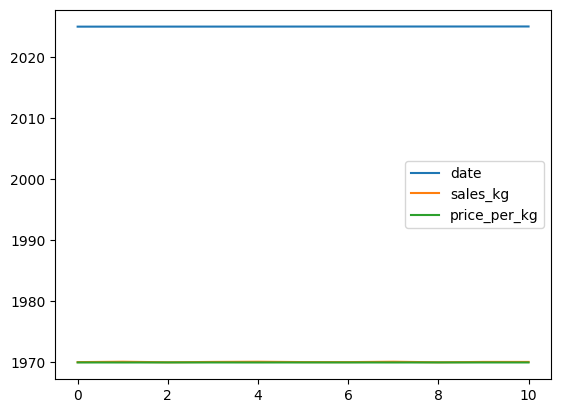

In [48]:
df_no_dups.plot()

## lets make better plot

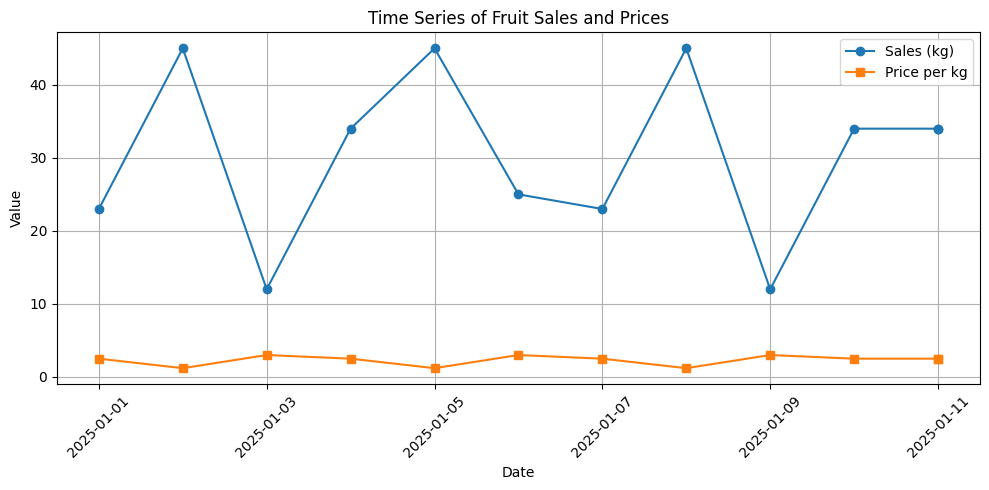

In [49]:
import matplotlib.pyplot as plt


df_time = df.set_index('date')# date as index for time series plotting

# lets plot over time
plt.figure(figsize=(10, 5))
plt.plot(df_time.index, df_time['sales_kg'], marker='o', label='Sales (kg)')
plt.plot(df_time.index, df_time['price_per_kg'], marker='s', label='Price per kg')

plt.title('Time Series of Fruit Sales and Prices')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


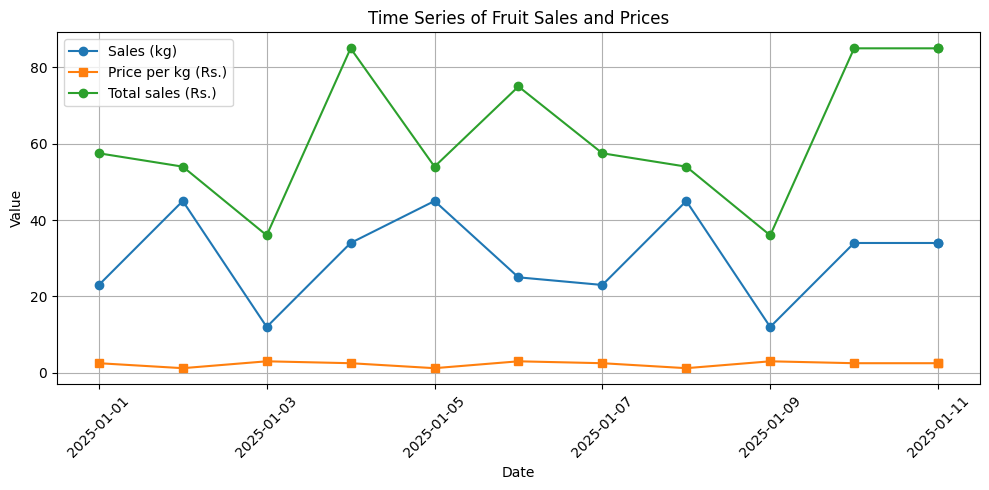

In [50]:
df['total'] = df['sales_kg'] * df['price_per_kg']

df_time = df.set_index('date')# date as index for time series plotting
# lets plot over time
plt.figure(figsize=(10, 5))
plt.plot(df_time.index, df_time['sales_kg'], marker='o', label='Sales (kg)')
plt.plot(df_time.index, df_time['price_per_kg'], marker='s', label='Price per kg (Rs.)')
plt.plot(df_time.index, df_time['total'], marker='o', label='Total sales (Rs.)')

plt.title('Time Series of Fruit Sales and Prices')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
# Drop duplicates by ignoring the 'date' column
df.drop_duplicates(subset=['fruit', 'sales_kg', 'price_per_kg', 'shop'])


,date,fruit,sales_kg,price_per_kg,shop,total
0,2025-01-01,apple,23,2.5,Bagar,57.5
1,2025-01-02,banana,45,1.2,Lamachour,54.0
2,2025-01-03,orange,12,3.0,Batulechour,36.0
3,2025-01-04,apple,34,2.5,Bagar,85.0
5,2025-01-06,orange,25,3.0,Batulechour,75.0


## aggregrations

In [52]:
# total sales per fruit
df.groupby('fruit')['sales_kg'].sum()


,sales_kg
fruit,
apple,182
banana,135
orange,49


In [53]:
# avg frut price
df.groupby('fruit')['price_per_kg'].mean()


,price_per_kg
fruit,
apple,2.5
banana,1.2
orange,3.0


In [54]:
# total saels per shop
df.groupby('shop')['total'].sum()


,total
shop,
Bagar,455.0
Batulechour,147.0
Lamachour,162.0


In [55]:
# sales stats for each shop
df.groupby('shop')['sales_kg'].agg(['min', 'max', 'mean'])


,min,max,mean
shop,,,
Bagar,23,34,30.333333
Batulechour,12,25,16.333333
Lamachour,45,45,45.000000


In [56]:
# daily total sales
df.groupby('date')['sales_kg'].sum()


,sales_kg
date,
2025-01-01,23
2025-01-02,45
2025-01-03,12
2025-01-04,34
2025-01-05,45
2025-01-06,25
2025-01-07,23
2025-01-08,45
2025-01-09,12


## frequency value count

In [57]:
df['fruit'].value_counts() #  how many times each unique fruit appears in the 'fruit' column?




,count
fruit,
apple,6
banana,3
orange,3


In [58]:
# summarizes each fruit's total and average sales, average price, and total revenue
df.groupby('fruit').agg({
    'sales_kg': ['sum', 'mean'],
    'price_per_kg': 'mean',
    'total': 'sum'
})


sales_kg            price_per_kg  total
            sum       mean         mean    sum
fruit                                         
apple       182  30.333333          2.5  455.0
banana      135  45.000000          1.2  162.0
orange       49  16.333333          3.0  147.0

# drop row cols

In [59]:
df.head()


,date,fruit,sales_kg,price_per_kg,shop,total
0,2025-01-01,apple,23,2.5,Bagar,57.5
1,2025-01-02,banana,45,1.2,Lamachour,54.0
2,2025-01-03,orange,12,3.0,Batulechour,36.0
3,2025-01-04,apple,34,2.5,Bagar,85.0
4,2025-01-05,banana,45,1.2,Lamachour,54.0


In [60]:
df.drop([0, 2]) # Drops rows with index 0 and 2
#  permanently drop with (inplace=True)


,date,fruit,sales_kg,price_per_kg,shop,total
1,2025-01-02,banana,45,1.2,Lamachour,54.0
3,2025-01-04,apple,34,2.5,Bagar,85.0
4,2025-01-05,banana,45,1.2,Lamachour,54.0
5,2025-01-06,orange,25,3.0,Batulechour,75.0
6,2025-01-07,apple,23,2.5,Bagar,57.5
7,2025-01-08,banana,45,1.2,Lamachour,54.0
8,2025-01-09,orange,12,3.0,Batulechour,36.0
9,2025-01-10,apple,34,2.5,Bagar,85.0
10,2025-01-11,apple,34,2.5,Bagar,85.0
11,2025-01-11,apple,34,2.5,Bagar,85.0


In [61]:
df.drop('price_per_kg', axis=1)#drop the 'price_per_kg' column

#  permanently drop with (inplace=True)



,date,fruit,sales_kg,shop,total
0,2025-01-01,apple,23,Bagar,57.5
1,2025-01-02,banana,45,Lamachour,54.0
2,2025-01-03,orange,12,Batulechour,36.0
3,2025-01-04,apple,34,Bagar,85.0
4,2025-01-05,banana,45,Lamachour,54.0
5,2025-01-06,orange,25,Batulechour,75.0
6,2025-01-07,apple,23,Bagar,57.5
7,2025-01-08,banana,45,Lamachour,54.0
8,2025-01-09,orange,12,Batulechour,36.0
9,2025-01-10,apple,34,Bagar,85.0
